# 🫁 CXR DenseNet121 — v6.1 (variante MÁS COMPLEJA · CPU · modelo independiente)
## TFM · Módulo de Imagen · Universidad de Salamanca

---

Variante **más potente** del CXR v6, manteniendo la viabilidad en CPU (i5-1135G7, sin GPU).
Modelo **independiente** (sin fusión). Hereda todo lo del v6 y añade más capacidad.

## 🆙 Qué añade respecto al v6

| Mejora | Detalle |
|---|---|
| **Cabeza más profunda y ancha** | 1024 → 768 → 384 → 192 → 6 (vs 1024→512→256→6 del v6) + rama de metadatos mayor |
| **Aumento en el espacio de embeddings** | Ruido gaussiano + **mixup** sobre los embeddings durante el entrenamiento de la cabeza (regulariza sin re-extraer imágenes) |
| **Ensemble (bagging) de K modelos** | La predicción de test es el **promedio de los K modelos** del K-fold (más robusto). es un promediado de modelos (bagging) sobre la misma tarea |
| **Más presupuesto** | Optuna 35 trials · K=5 · 60 épocas |

Se mantiene: backbone **DenseNet121 (CheXNet)** congelado + **embeddings cacheados** (coste ≈ el mismo),
**negativos derivados por exclusividad** (No Finding), **masking de NaN/−1 intacto**, `pos_weight`
dinámico, BCE/focal, **calibración isotónica**, metadatos de 18 dims, y salidas ricas
(matrices de confusión, ROC, PR, calibración, AUC por etiqueta).

## 🛡️ Masking (sin cambios)

NaN no cubierto → enmascarado · −1 → según `uncertainty_policy` · NaN cubierto por exclusividad → 0 observado.

## ⏱️ Coste: ≈ 1 h la 1ª vez (embeddings cacheados); el ensemble y el aumento son baratos sobre la caché.


In [1]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
try:
    import torch  # noqa: F401
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","torch","torchvision",
                    "--index-url","https://download.pytorch.org/whl/cpu","-q"], check=True)
for pkg in ["torchxrayvision","optuna","scikit-learn","pandas","numpy","matplotlib","seaborn","tqdm"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"], check=True)
print("Dependencias instaladas.")


Dependencias instaladas.


In [2]:
# CELDA 2 · IMPORTS / SEMILLAS / DISPOSITIVO
import os, gc, json, time, copy, random, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, WeightedRandomSampler
import torchxrayvision as xrv
from sklearn.model_selection import KFold
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.isotonic import IsotonicRegression
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING); warnings.filterwarnings("ignore")
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
N_CORES=4; torch.set_num_threads(N_CORES)
os.environ["OMP_NUM_THREADS"]=str(N_CORES); os.environ["MKL_NUM_THREADS"]=str(N_CORES)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} · xrv {xrv.__version__} · {DEVICE} · hilos {torch.get_num_threads()}")


c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.8.0+cpu · xrv 1.4.0 · cpu · hilos 4


In [3]:
# CELDA 3 · RUTAS Y CONSTANTES
BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV_DIR=BASE/"data_csv"/"clean"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV_DIR/"train_clean.csv",CSV_DIR/"val_clean.csv",CSV_DIR/"test_clean.csv"
NPY=BASE/"data_npy"
CXR_TRAIN_NPY,CXR_VAL_NPY,CXR_TEST_NPY=NPY/"train"/"cxr_train.npy",NPY/"val"/"cxr_val.npy",NPY/"test"/"cxr_test.npy"
HADM_TRAIN_NPY,HADM_VAL_NPY,HADM_TEST_NPY=NPY/"train"/"hadm_id_train.npy",NPY/"val"/"hadm_id_val.npy",NPY/"test"/"hadm_id_test.npy"
OUTPUT_DIR=Path("outputs_cxr_densenet121_v6_1").resolve(); OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
EMB_DIR=OUTPUT_DIR/"embeddings"; EMB_DIR.mkdir(parents=True,exist_ok=True)
FIG_DIR=OUTPUT_DIR/"figuras"; FIG_DIR.mkdir(parents=True,exist_ok=True)
print("Salidas en:", OUTPUT_DIR)

LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY_LABELS=[l for l in LABELS if l!=NO_FINDING]; CORE_LABELS=["Cardiomegaly","Edema","Pleural Effusion"]
IMG_SIZE=224; XRV_RANGE=1024.0; BACKBONE_WEIGHTS="densenet121-res224-all"
DERIVE_NEGATIVES_FROM_EXCLUSIVITY=True

GENDER_MAP={0:0,1:1,"0":0,"1":1,"M":1,"F":0}
RACE_MAP={"UNKNOWN":0,"WHITE":1,"BLACK":2,"ASIAN":3,"HISPANIC_LATINO":4,"OTHER_KNOWN":0}
ADMISSION_MAP={"SCHEDULED":0,"EMERGENCY":1,"OBSERVATION":2,"URGENT":3}
ADM_LOC_MAP={"EMERGENCY_ROOM":0,"REFERRAL":1,"TRANSFER":2,"INTRA_HOSPITAL":3}
CXR_VIEW_MAP={"AP":0,"PA":1}; RACE_ONEHOT=5
META_DIM=1+1+RACE_ONEHOT+len(ADMISSION_MAP)+len(ADM_LOC_MAP)+1+len(CXR_VIEW_MAP)  # 18

# --- v6.1: más presupuesto + aumento en embeddings ---
OPTUNA_TRIALS,K_FOLDS=35,5
TUNE_EPOCHS,TUNE_PATIENCE=24,6
FINAL_EPOCHS,FINAL_PATIENCE=60,10
HEAD_BATCH,EMB_BATCH=128,16
EMB_NOISE_STD=0.10   # aumento: desv. del ruido gaussiano sobre embeddings
MIXUP_ALPHA=0.2      # aumento: intensidad de mixup (0 = desactivado)
print(f"v6.1 · META_DIM={META_DIM} · trials={OPTUNA_TRIALS} K={K_FOLDS} épocas={FINAL_EPOCHS}")


Salidas en: outputs_cxr_densenet121_v6_1
v6.1 · META_DIM=18 · trials=35 K=5 épocas=60


In [4]:
# CELDA 4 · CARGA Y ALINEACIÓN
def load_split(csv,cxr,hadm,name):
    df=pd.read_csv(csv,sep=";"); h=np.load(hadm,allow_pickle=True); h2i={int(x):i for i,x in enumerate(h)}
    df["_npy_idx"]=df["hadm_id"].map(lambda z:h2i.get(int(z),-1)); n0=len(df)
    df=df[df["_npy_idx"]>=0].reset_index(drop=True); a=np.load(cxr,mmap_mode="r")
    print(f"{name:5s}: CSV={n0:,} con imagen={len(df):,} · CXR {a.shape}"); return df,a
df_train,cxr_train=load_split(TRAIN_CSV,CXR_TRAIN_NPY,HADM_TRAIN_NPY,"train")
df_val,cxr_val=load_split(VAL_CSV,CXR_VAL_NPY,HADM_VAL_NPY,"val")
df_test,cxr_test=load_split(TEST_CSV,CXR_TEST_NPY,HADM_TEST_NPY,"test")


train: CSV=10,000 con imagen=10,000 · CXR (10000, 3, 320, 320)
val  : CSV=750 con imagen=750 · CXR (750, 3, 320, 320)
test : CSV=464 con imagen=464 · CXR (4640, 3, 320, 320)


In [5]:
# CELDA 5 · OBJETIVOS (masking + negativos derivados)
def build_targets(df,uncertainty_policy="zeros",derive=DERIVE_NEGATIVES_FROM_EXCLUSIVITY,verbose=False):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=np.zeros((N,N_LABELS),np.float32); mask=np.zeros((N,N_LABELS),np.float32)
    mask[~np.isnan(raw)]=1.0; labels[raw==1]=1.0
    unc=(raw==-1); labels[unc]=1.0 if uncertainty_policy=="ones" else 0.0
    nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]; n_dp=n_dn=n_c=0
    if derive:
        nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; mask[f,j]=1.0; n_dp+=int(f.sum())
        n_c=int((nfp[:,None]&(raw[:,pc]==1)).sum())
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; mask[fn,nf]=1.0; n_dn=int(fn.sum())
    if verbose: print(f"   Neg. derivados patologías={n_dp:,} · No Finding={n_dn:,} · contradicciones={n_c:,}")
    return labels,mask
print("== Balance train =="); _y,_m=build_targets(df_train,"zeros",verbose=True)
for j,l in enumerate(LABELS):
    s=_m[:,j]==1; print(f"   {l:18s} pos={int((_y[s,j]==1).sum()):5d} neg={int((_y[s,j]==0).sum()):5d}")


== Balance train ==
   Neg. derivados patologías=6,091 · No Finding=7,691 · contradicciones=0
   Atelectasis        pos= 2867 neg= 2052
   Cardiomegaly       pos= 3346 neg= 2495
   Edema              pos= 2067 neg= 3735
   Lung Opacity       pos= 3108 neg= 1733
   No Finding         pos= 1368 neg= 7691
   Pleural Effusion   pos= 3618 neg= 3194


In [6]:
# CELDA 6 · METADATOS (18 dims)
AGE_MIN,AGE_MAX=float(df_train["age"].min()),float(df_train["age"].max())
HRS_MIN,HRS_MAX=float(df_train["hours_adm_to_cxr"].min()),float(df_train["hours_adm_to_cxr"].max())
def build_metadata(df):
    N=len(df); M=np.zeros((N,META_DIM),np.float32)
    for i,(_,r) in enumerate(df.iterrows()):
        o=0
        M[i,o]=(float(r.get("age",AGE_MIN))-AGE_MIN)/(AGE_MAX-AGE_MIN+1e-8); o+=1
        M[i,o]=float(GENDER_MAP.get(r.get("gender",0),0)); o+=1
        M[i,o+RACE_MAP.get(str(r.get("race","UNKNOWN")).upper(),0)]=1.0; o+=RACE_ONEHOT
        M[i,o+ADMISSION_MAP.get(str(r.get("admission_type","EMERGENCY")).upper(),1)]=1.0; o+=len(ADMISSION_MAP)
        M[i,o+ADM_LOC_MAP.get(str(r.get("admission_location","EMERGENCY_ROOM")).upper(),0)]=1.0; o+=len(ADM_LOC_MAP)
        M[i,o]=(float(r.get("hours_adm_to_cxr",HRS_MIN))-HRS_MIN)/(HRS_MAX-HRS_MIN+1e-8); o+=1
        M[i,o+CXR_VIEW_MAP.get(str(r.get("cxr_view","AP")).upper(),0)]=1.0; o+=len(CXR_VIEW_MAP)
    return M
meta_train,meta_val,meta_test=build_metadata(df_train),build_metadata(df_val),build_metadata(df_test)
print(f"Metadatos {meta_train.shape} {meta_val.shape} {meta_test.shape}")


Metadatos (10000, 18) (750, 18) (464, 18)


In [7]:
# CELDA 7 · PREPROCESADO DE IMAGEN (alineado con torchxrayvision)
class CXRImageDataset(Dataset):
    def __init__(s,df,cxr): s.idx=df["_npy_idx"].to_numpy(); s.cxr=cxr
    def __len__(s): return len(s.idx)
    def __getitem__(s,i):
        a=np.asarray(s.cxr[int(s.idx[i])],np.float32); g=a[0] if a.ndim==3 else a
        g=(g-g.min())/(g.max()-g.min()+1e-8); g=(2.0*g-1.0)*XRV_RANGE
        t=torch.from_numpy(g)[None,None]
        return F.interpolate(t,size=(IMG_SIZE,IMG_SIZE),mode="bilinear",align_corners=False)[0]
print("Preprocesado listo.")


Preprocesado listo.


In [8]:
# CELDA 8 · BACKBONE + EMBEDDINGS
def load_backbone():
    m=xrv.models.DenseNet(weights=BACKBONE_WEIGHTS); m.eval()
    for p in m.parameters(): p.requires_grad=False
    return m.to(DEVICE)
@torch.no_grad()
def extract_embeddings(model,df,cxr,desc):
    loader=DataLoader(CXRImageDataset(df,cxr),batch_size=EMB_BATCH,shuffle=False,num_workers=0); out=[]
    for x in tqdm(loader,desc=desc,leave=False):
        f=model.features(x.to(DEVICE)); f=F.relu(f,inplace=True)
        out.append(F.adaptive_avg_pool2d(f,(1,1)).reshape(f.shape[0],-1).cpu().numpy())
    return np.concatenate(out,0).astype(np.float32)
print("Backbone listo.")


Backbone listo.


In [9]:
# CELDA 9 · CALCULAR / CARGAR EMBEDDINGS
PT={s:EMB_DIR/f"emb_{s}.npy" for s in ["train","val","test"]}
if all(p.exists() for p in PT.values()):
    emb_train,emb_val,emb_test=np.load(PT["train"]),np.load(PT["val"]),np.load(PT["test"]); print("Embeddings de caché.")
else:
    EMB_DIR.mkdir(parents=True,exist_ok=True); t0=time.time(); bb=load_backbone()
    emb_train=extract_embeddings(bb,df_train,cxr_train,"train"); np.save(PT["train"],emb_train)
    emb_val=extract_embeddings(bb,df_val,cxr_val,"val"); np.save(PT["val"],emb_val)
    emb_test=extract_embeddings(bb,df_test,cxr_test,"test"); np.save(PT["test"],emb_test)
    del bb; gc.collect(); print(f"Embeddings en {(time.time()-t0)/60:.1f} min.")
EMB_DIM=emb_train.shape[1]; print(f"EMB_DIM={EMB_DIM} · train {emb_train.shape}")


Embeddings en 30.3 min.
EMB_DIM=1024 · train (10000, 1024)


In [10]:
# CELDA 10 · CABEZA PROFUNDA + PÉRDIDA + MÉTRICAS
class LabelCorrelation(nn.Module):
    def __init__(s,n=N_LABELS):
        super().__init__(); s.lin=nn.Linear(n,n,bias=False); nn.init.eye_(s.lin.weight)
        s.lin.weight.data*=0.1; s.norm=nn.LayerNorm(n)
    def forward(s,x): return s.norm(x+s.lin(x))

class CXRHeadDeep(nn.Module):
    # v6.1: 1024 -> 768 -> 384 -> 192 -> 6 + rama de metadatos mayor.
    def __init__(s,emb_dim=EMB_DIM,dropout=0.3,use_corr=True,use_meta=True):
        super().__init__(); s.use_meta=use_meta
        s.img=nn.Sequential(nn.Linear(emb_dim,768),nn.BatchNorm1d(768),nn.ReLU(inplace=True))
        if use_meta:
            s.meta=nn.Sequential(nn.Linear(META_DIM,96),nn.BatchNorm1d(96),nn.ReLU(inplace=True)); fused=768+96
        else: s.meta=None; fused=768
        s.head=nn.Sequential(
            nn.Dropout(dropout), nn.Linear(fused,384),nn.BatchNorm1d(384),nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(384,192),nn.BatchNorm1d(192),nn.ReLU(inplace=True),
            nn.Dropout(dropout*0.5), nn.Linear(192,N_LABELS))
        s.corr=LabelCorrelation() if use_corr else None
        for m in s.head.modules():
            if isinstance(m,nn.Linear):
                nn.init.kaiming_normal_(m.weight,nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(s,emb,meta=None):
        z=s.img(emb)
        if s.use_meta and meta is not None: z=torch.cat([z,s.meta(meta)],1)
        lo=s.head(z); return s.corr(lo) if s.corr is not None else lo

class MaskedLoss(nn.Module):
    def __init__(s,pos_weight,loss_type="bce",focal_gamma=2.0):
        super().__init__(); s.register_buffer("pw",pos_weight); s.lt=loss_type; s.g=focal_gamma
    def forward(s,logits,labels,mask):
        pw=s.pw.to(logits.device)
        if s.lt=="focal":
            bce=F.binary_cross_entropy_with_logits(logits,labels,pos_weight=pw,reduction="none")
            p=torch.sigmoid(logits); pt=labels*p+(1-labels)*(1-p); loss=((1-pt)**s.g)*bce
        else: loss=F.binary_cross_entropy_with_logits(logits,labels,pos_weight=pw,reduction="none")
        loss=loss*mask; return loss.sum()/mask.sum().clamp(min=1e-8)

def dynamic_pos_weights(y,m,clip=10.0):
    w=np.ones(N_LABELS,np.float32)
    for j in range(N_LABELS):
        s=m[:,j]==1; pos=(y[s,j]==1).sum(); neg=(y[s,j]==0).sum(); w[j]=np.clip(neg/max(pos,1),1/clip,clip)
    return torch.tensor(w,dtype=torch.float32)

def sample_weights_by_rarity(y,m):
    combo=[tuple(int(v) for v in (y[i]*m[i]).astype(int)) for i in range(len(y))]
    c=Counter(combo); return torch.tensor([1.0/c[k] for k in combo],dtype=torch.double)

def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        thr=thresholds.get(l,0.5); pred=(yp>=thr).astype(float)
        if npos>=2 and nneg>=2: auc=roc_auc_score(yt,yp); ap=average_precision_score(yt,yp)
        else: auc=ap=float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum())
        fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),
                "sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),"n_pos":npos,"n_neg":nneg,
                "thr":thr,"TP":tp,"TN":tn,"FP":fp,"FN":fn}
    def mac(g):
        v=[res[l]["AUC"] for l in g if not np.isnan(res[l]["AUC"])]; return float(np.mean(v)) if v else float("nan")
    res["macro_AUC_core"]=mac(CORE_LABELS); res["macro_AUC_path"]=mac(PATHOLOGY_LABELS); return res

def best_thresholds_by_f1(probs,labels,mask,grid=None):
    if grid is None: grid=np.linspace(0.05,0.95,37)
    thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
print("Cabeza profunda y utilidades listas.")


Cabeza profunda y utilidades listas.


In [11]:
# CELDA 11 · ENTRENAMIENTO con AUMENTO EN EMBEDDINGS (ruido + mixup)
@torch.no_grad()
def predict_head(head,emb,meta):
    head.eval(); out=[]
    for i in range(0,len(emb),512):
        out.append(torch.sigmoid(head(torch.tensor(emb[i:i+512]).to(DEVICE),
                                       torch.tensor(meta[i:i+512]).to(DEVICE))).cpu().numpy())
    return np.concatenate(out,0)

def train_head(emb_tr,meta_tr,y_tr,m_tr,emb_va,meta_va,y_va,m_va,cfg,n_epochs,patience):
    crit=MaskedLoss(dynamic_pos_weights(y_tr,m_tr),cfg.get("loss_type","bce")).to(DEVICE)
    head=CXRHeadDeep(EMB_DIM,cfg["dropout"],cfg["use_corr"],cfg["use_meta"]).to(DEVICE)
    opt=torch.optim.AdamW(head.parameters(),lr=cfg["lr"],weight_decay=cfg["weight_decay"])
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=n_epochs,eta_min=1e-7)
    ds=TensorDataset(torch.tensor(emb_tr),torch.tensor(meta_tr),torch.tensor(y_tr),torch.tensor(m_tr))
    if cfg.get("use_sampler",False):
        sw=sample_weights_by_rarity(y_tr,m_tr)
        loader=DataLoader(ds,batch_size=HEAD_BATCH,sampler=WeightedRandomSampler(sw,len(sw),True),drop_last=True)
    else:
        loader=DataLoader(ds,batch_size=HEAD_BATCH,shuffle=True,drop_last=True)
    noise=cfg.get("emb_noise",EMB_NOISE_STD); mix=cfg.get("mixup",MIXUP_ALPHA)
    best,bs,wait=-1.0,None,0; hist={"train_loss":[],"val_auc":[]}
    for ep in range(n_epochs):
        head.train(); tl,nb=0.0,0
        for eb,mb,yb,msb in loader:
            eb,mb,yb,msb=eb.to(DEVICE),mb.to(DEVICE),yb.to(DEVICE),msb.to(DEVICE)
            if noise>0: eb=eb+torch.randn_like(eb)*noise          # aumento: ruido gaussiano
            if mix>0:                                              # aumento: mixup en embeddings
                lam=float(np.random.beta(mix,mix)); perm=torch.randperm(eb.size(0))
                eb=lam*eb+(1-lam)*eb[perm]; mb=lam*mb+(1-lam)*mb[perm]
                yb2,msb2=yb[perm],msb[perm]
                opt.zero_grad(); logit=head(eb,mb)
                loss=lam*crit(logit,yb,msb)+(1-lam)*crit(logit,yb2,msb2)
            else:
                opt.zero_grad(); loss=crit(head(eb,mb),yb,msb)
            loss.backward(); torch.nn.utils.clip_grad_norm_(head.parameters(),1.0); opt.step(); tl+=loss.item(); nb+=1
        sched.step()
        sc=multilabel_metrics(predict_head(head,emb_va,meta_va),y_va,m_va)["macro_AUC_path"]
        hist["train_loss"].append(tl/max(nb,1)); hist["val_auc"].append(sc)
        if not np.isnan(sc) and sc>best+1e-4: best,bs,wait=sc,copy.deepcopy(head.state_dict()),0
        else:
            wait+=1
            if wait>=patience: break
    if bs is not None: head.load_state_dict(bs)
    return head,best,hist
print("Entrenamiento con aumento (ruido+mixup) listo.")


Entrenamiento con aumento (ruido+mixup) listo.


In [12]:
# CELDA 12 · OPTUNA (CV interno 3-fold)
def objective(trial):
    cfg={"lr":trial.suggest_float("lr",1e-4,5e-3,log=True),
         "weight_decay":trial.suggest_float("weight_decay",1e-5,1e-3,log=True),
         "dropout":trial.suggest_float("dropout",0.1,0.5),
         "use_corr":trial.suggest_categorical("use_corr",[True,False]),
         "use_meta":trial.suggest_categorical("use_meta",[True,False]),
         "use_sampler":trial.suggest_categorical("use_sampler",[True,False]),
         "loss_type":trial.suggest_categorical("loss_type",["bce","focal"]),
         "emb_noise":trial.suggest_float("emb_noise",0.0,0.15),
         "mixup":trial.suggest_categorical("mixup",[0.0,0.2,0.4]),
         "policy":trial.suggest_categorical("policy",["zeros","ones"])}
    y_all,m_all=build_targets(df_train,cfg["policy"]); kf=KFold(3,shuffle=True,random_state=SEED); sc=[]
    for tr,va in kf.split(np.arange(len(df_train))):
        h,_,_=train_head(emb_train[tr],meta_train[tr],y_all[tr],m_all[tr],
                         emb_train[va],meta_train[va],y_all[va],m_all[va],cfg,TUNE_EPOCHS,TUNE_PATIENCE)
        sc.append(multilabel_metrics(predict_head(h,emb_train[va],meta_train[va]),y_all[va],m_all[va])["macro_AUC_path"])
        del h; gc.collect()
    return float(np.nanmean(sc))
t0=time.time(); study=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective,n_trials=OPTUNA_TRIALS,show_progress_bar=True); BEST=study.best_params
print(f"\nOptuna {(time.time()-t0)/60:.1f} min · mejor macroAUC_path={study.best_value:.4f}")
for k,v in BEST.items(): print(f"   {k:14s} = {v}")


Best trial: 34. Best value: 0.822958: 100%|██████████| 35/35 [51:45<00:00, 88.73s/it] 


Optuna 51.8 min · mejor macroAUC_path=0.8230
   lr             = 0.0036760471712114816
   weight_decay   = 6.506225682088106e-05
   dropout        = 0.4996290959748867
   use_corr       = False
   use_meta       = False
   use_sampler    = False
   loss_type      = bce
   emb_noise      = 0.08372225559946682
   mixup          = 0.4
   policy         = ones


In [13]:
# CELDA 13 · K-FOLD: estimación CV + ENSEMBLE (bagging) de K modelos
cfg=dict(BEST)
y_train,m_train=build_targets(df_train,cfg["policy"])
y_val,m_val=build_targets(df_val,cfg["policy"]); y_test,m_test=build_targets(df_test,cfg["policy"])
kf=KFold(K_FOLDS,shuffle=True,random_state=SEED)
fold_rows=[]; acc_val=np.zeros((len(df_val),N_LABELS),np.float32); acc_test=np.zeros((len(df_test),N_LABELS),np.float32)
histories=[]
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    h,_,hist=train_head(emb_train[tr],meta_train[tr],y_train[tr],m_train[tr],
                        emb_train[va],meta_train[va],y_train[va],m_train[va],cfg,FINAL_EPOCHS,FINAL_PATIENCE)
    mm=multilabel_metrics(predict_head(h,emb_train[va],meta_train[va]),y_train[va],m_train[va]); fold_rows.append(mm)
    acc_val+=predict_head(h,emb_val,meta_val); acc_test+=predict_head(h,emb_test,meta_test); histories.append(hist)
    print(f"Fold {k+1}/{K_FOLDS}: macroAUC_path={mm['macro_AUC_path']:.4f} core={mm['macro_AUC_core']:.4f}")
    del h; gc.collect()
val_pred_raw=acc_val/K_FOLDS; test_pred_raw=acc_test/K_FOLDS   # ENSEMBLE = promedio de los K modelos
cv_core=[f["macro_AUC_core"] for f in fold_rows]; cv_path=[f["macro_AUC_path"] for f in fold_rows]
print(f"\nCV {K_FOLDS}-fold · core={np.nanmean(cv_core):.4f}±{np.nanstd(cv_core):.4f} · path={np.nanmean(cv_path):.4f}±{np.nanstd(cv_path):.4f}")


Fold 1/5: macroAUC_path=0.8272 core=0.8334
Fold 2/5: macroAUC_path=0.8169 core=0.8274
Fold 3/5: macroAUC_path=0.8224 core=0.8365
Fold 4/5: macroAUC_path=0.8274 core=0.8406
Fold 5/5: macroAUC_path=0.8248 core=0.8347

CV 5-fold · core=0.8345±0.0043 · path=0.8237±0.0039


In [14]:
# CELDA 14 · CALIBRACIÓN (val) del ensemble + umbrales
calibrators={}
for j,l in enumerate(LABELS):
    s=m_val[:,j]==1; yt=y_val[s,j]; yp=val_pred_raw[s,j]
    if len(np.unique(yt))<2: calibrators[l]=None; continue
    iso=IsotonicRegression(out_of_bounds="clip"); iso.fit(yp,yt); calibrators[l]=iso
def apply_cal(p):
    o=p.copy()
    for j,l in enumerate(LABELS):
        if calibrators[l] is not None: o[:,j]=calibrators[l].predict(p[:,j])
    return o
val_pred=apply_cal(val_pred_raw); test_pred=apply_cal(test_pred_raw)
thr_val=best_thresholds_by_f1(val_pred,y_val,m_val)
torch.save({"config":cfg,"thresholds":thr_val,"k_folds":K_FOLDS}, OUTPUT_DIR/"config_v6_1.pt")
print("Ensemble calibrado · umbrales fijados.")


Ensemble calibrado · umbrales fijados.


In [15]:
# CELDA 15 · EVALUACIÓN EN TEST + TABLA
M=multilabel_metrics(test_pred,y_test,m_test,thresholds=thr_val); rows=[]
print(f"{'Etiqueta':18s} {'AUC':>7} {'AP':>7} {'F1':>7} {'Sens':>6} {'Spec':>6} {'N+':>5} {'N-':>5}")
print("-"*74)
for l in LABELS:
    m=M[l]; auc=f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    print(f"{l:18s} {auc:>7} {m['AP']:7.4f} {m['F1']:7.4f} {m['sens']:6.3f} {m['spec']:6.3f} {m['n_pos']:5d} {m['n_neg']:5d}")
    rows.append({"label":l,**{k:m[k] for k in ["AUC","AP","F1","sens","spec","n_pos","n_neg","TP","TN","FP","FN","thr"]}})
print("-"*74); print(f"{'MACRO core':18s} {M['macro_AUC_core']:.4f}  ·  MACRO patol. {M['macro_AUC_path']:.4f}")
pd.DataFrame(rows).to_csv(OUTPUT_DIR/"metrics_per_label_v6_1.csv",index=False)
summary={"version":"CXR v6.1 DenseNet121 + cabeza profunda + aumento embeddings + ensemble","best_config":BEST,
         "cv_macro_core":[float(np.nanmean(cv_core)),float(np.nanstd(cv_core))],
         "cv_macro_path":[float(np.nanmean(cv_path)),float(np.nanstd(cv_path))],
         "test_macro_core":M["macro_AUC_core"],"test_macro_path":M["macro_AUC_path"],
         "test_per_label":{l:M[l] for l in LABELS}}
with open(OUTPUT_DIR/"summary_v6_1.json","w",encoding="utf-8") as f: json.dump(summary,f,indent=2,default=str,ensure_ascii=False)
print("Guardados metrics_per_label_v6_1.csv y summary_v6_1.json")


Etiqueta               AUC      AP      F1   Sens   Spec    N+    N-
--------------------------------------------------------------------------
Atelectasis         0.7791  0.8576  0.8464  0.896  0.507   163    73
Cardiomegaly        0.7609  0.7889  0.7778  0.939  0.297   164   111
Edema               0.8215  0.7802  0.7491  0.851  0.643   121   143
Lung Opacity        0.7886  0.8375  0.8103  0.881  0.475   143    80
No Finding          0.7520  0.4080  0.4277  0.536  0.808    69   349
Pleural Effusion    0.8534  0.8556  0.8120  0.823  0.748   181   147
--------------------------------------------------------------------------
MACRO core         0.8119  ·  MACRO patol. 0.8007
Guardados metrics_per_label_v6_1.csv y summary_v6_1.json


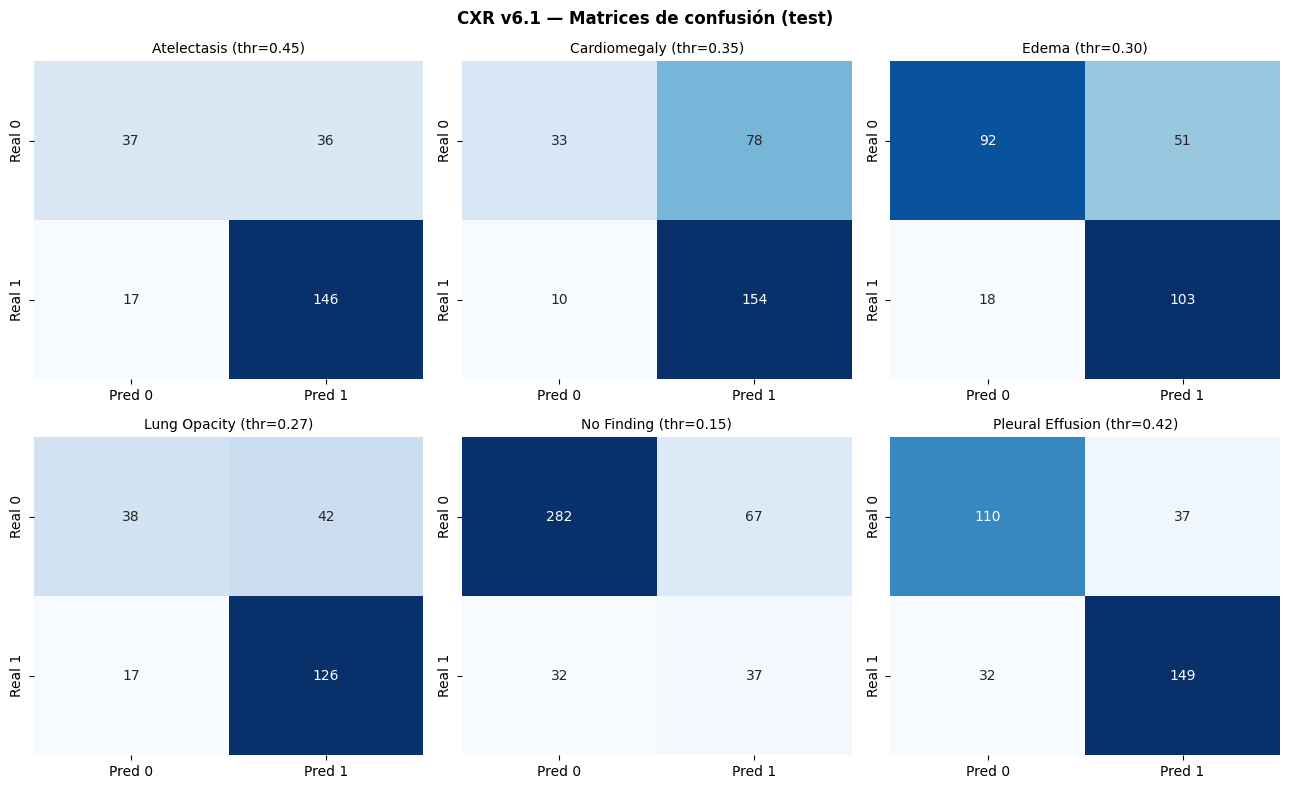

Matrices de confusión guardadas.


In [16]:
# CELDA 16 · MATRICES DE CONFUSIÓN
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle("CXR v6.1 — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(test_pred[s,j]>=thr_val.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    cm=confusion_matrix(yt,yp,labels=[0,1])
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False,ax=ax,
                xticklabels=["Pred 0","Pred 1"],yticklabels=["Real 0","Real 1"])
    ax.set_title(f"{l} (thr={thr_val.get(l,0.5):.2f})",fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR/"confusion_matrices_v6_1.png",dpi=150,bbox_inches="tight"); plt.show()
print("Matrices de confusión guardadas.")


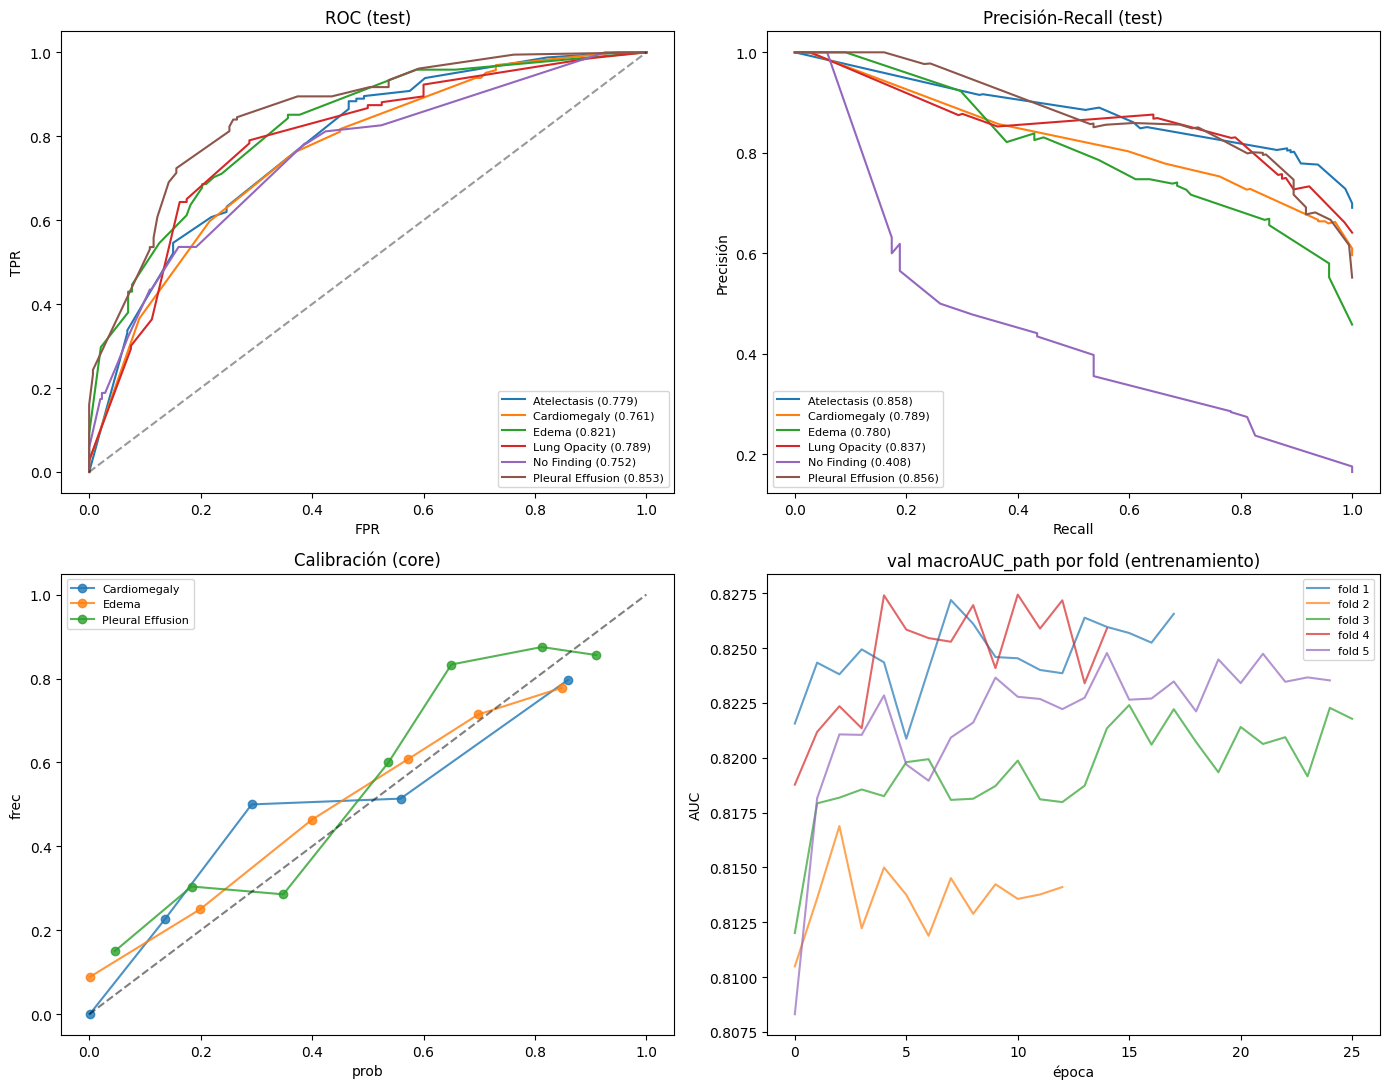

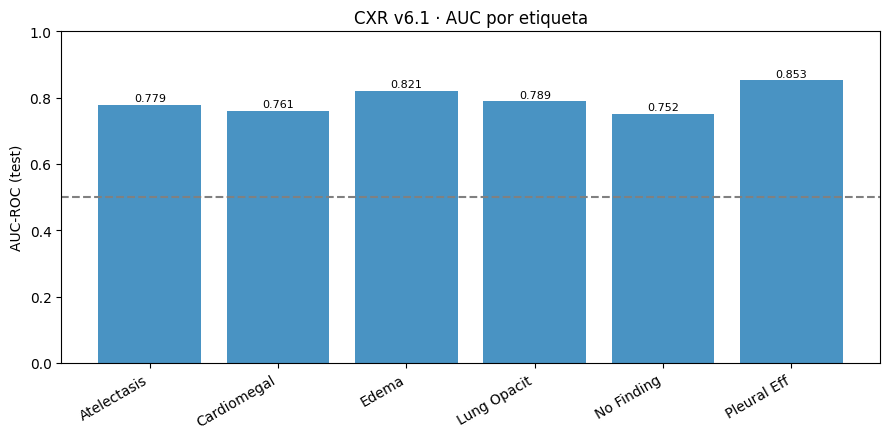

Figuras guardadas en outputs_cxr_densenet121_v6_1\figuras


In [17]:
# CELDA 17 · CURVAS ROC / PR / CALIBRACIÓN / ENTRENAMIENTO (por fold) + AUC
fig,axes=plt.subplots(2,2,figsize=(14,11))
ax=axes[0,0]
for j,l in enumerate(LABELS):
    s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    if len(np.unique(yt))<2: continue
    fpr,tpr,_=roc_curve(yt,yp); ax.plot(fpr,tpr,label=f"{l} ({M[l]['AUC']:.3f})")
ax.plot([0,1],[0,1],"k--",alpha=0.4); ax.set_title("ROC (test)"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=8)
ax=axes[0,1]
for j,l in enumerate(LABELS):
    s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    if len(np.unique(yt))<2: continue
    pr,rc,_=precision_recall_curve(yt,yp); ax.plot(rc,pr,label=f"{l} ({M[l]['AP']:.3f})")
ax.set_title("Precisión-Recall (test)"); ax.set_xlabel("Recall"); ax.set_ylabel("Precisión"); ax.legend(fontsize=8)
ax=axes[1,0]
for l in CORE_LABELS:
    j=LABELS.index(l); s=m_test[:,j]==1; yt=y_test[s,j]; yp=test_pred[s,j]
    bins=np.linspace(0,1,9); idx=np.digitize(yp,bins)-1; xs,ys=[],[]
    for b in range(len(bins)-1):
        mb=idx==b
        if mb.sum()>5: xs.append(yp[mb].mean()); ys.append(yt[mb].mean())
    ax.plot(xs,ys,"o-",label=l,alpha=0.8)
ax.plot([0,1],[0,1],"k--",alpha=0.5); ax.set_title("Calibración (core)"); ax.set_xlabel("prob"); ax.set_ylabel("frec"); ax.legend(fontsize=8)
ax=axes[1,1]
for k,h in enumerate(histories): ax.plot(h["val_auc"],alpha=0.7,label=f"fold {k+1}")
ax.set_title("val macroAUC_path por fold (entrenamiento)"); ax.set_xlabel("época"); ax.set_ylabel("AUC"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/"curvas_v6_1.png",dpi=150,bbox_inches="tight"); plt.show()
fig2,ax=plt.subplots(figsize=(9,4.5)); aucs=[M[l]["AUC"] for l in LABELS]
ax.bar(range(N_LABELS),[0 if np.isnan(a) else a for a in aucs],
       color=["#c0392b" if (np.isnan(a) or a<0.55) else "#2980b9" for a in aucs],alpha=0.85)
ax.axhline(0.5,color="gray",ls="--"); ax.set_xticks(range(N_LABELS)); ax.set_xticklabels([l[:11] for l in LABELS],rotation=30,ha="right")
ax.set_ylim(0,1); ax.set_ylabel("AUC-ROC (test)"); ax.set_title("CXR v6.1 · AUC por etiqueta")
for i,a in enumerate(aucs):
    if not np.isnan(a): ax.text(i,a+0.01,f"{a:.3f}",ha="center",fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR/"auc_por_etiqueta_v6_1.png",dpi=150,bbox_inches="tight"); plt.show()
print("Figuras guardadas en", FIG_DIR)


In [18]:
# CELDA 18 · EQUIDAD POR SUBGRUPO
dft=df_test.reset_index(drop=True)
for col,lab in [("gender","GÉNERO"),("cxr_view","VISTA"),("race","RAZA"),("admission_type","INGRESO")]:
    if col not in dft.columns: continue
    print(f"\n-- AUC macro (patologías) por {lab} --")
    for v in sorted(dft[col].dropna().unique(),key=str):
        idx=dft.index[dft[col]==v].to_numpy()
        if len(idx)<15: print(f"   {str(v):22s} n={len(idx):4d} (insuficiente)"); continue
        mm=multilabel_metrics(test_pred[idx],y_test[idx],m_test[idx])
        print(f"   {str(v):22s} n={len(idx):4d}  macroAUC_path={mm['macro_AUC_path']:.4f}")
print("\nEquidad completada.")



-- AUC macro (patologías) por GÉNERO --
   0                      n= 184  macroAUC_path=0.8212
   1                      n= 280  macroAUC_path=0.7879

-- AUC macro (patologías) por VISTA --
   AP                     n= 388  macroAUC_path=0.7743
   PA                     n=  76  macroAUC_path=0.8344

-- AUC macro (patologías) por RAZA --
   ASIAN                  n=  15  macroAUC_path=0.9176
   BLACK                  n=  58  macroAUC_path=0.7207
   HISPANIC_LATINO        n=  21  macroAUC_path=0.6967
   OTHER_KNOWN            n=   3 (insuficiente)
   UNKNOWN                n=  52  macroAUC_path=0.8701
   WHITE                  n= 315  macroAUC_path=0.8018

-- AUC macro (patologías) por INGRESO --
   EMERGENCY              n= 322  macroAUC_path=0.8039
   OBSERVATION            n=  66  macroAUC_path=0.8241
   SCHEDULED              n=  34  macroAUC_path=0.7314
   URGENT                 n=  42  macroAUC_path=0.7901

Equidad completada.


---
## ✅ Resumen — CXR v6.1
Variante más compleja del v6: **cabeza profunda**, **aumento en embeddings (ruido + mixup)**, **ensemble (bagging) de K modelos**, más presupuesto de búsqueda y épocas. Mantiene backbone DenseNet121 congelado (CPU-viable), negativos derivados, masking intacto, calibración y salidas ricas.
